In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("../../..").resolve()))

import pandas as pd
from src.utils.db import get_connection
import ast
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
import numpy as np
from scipy import stats

warnings.filterwarnings('ignore')

# plt.rcParams['font.family'] = 'AppleGothic'    # Mac
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
plt.rcParams['axes.unicode_minus'] = False

conn = get_connection()

reviews_df = pd.read_sql(
    "SELECT * FROM steam_indie_reviews",
    conn
)

metadata_df = pd.read_sql(
    "SELECT * FROM steam_indie_9692",
    conn
)

df_details = pd.read_sql(
    "SELECT * FROM steam_app_details",
    conn
)

metadata_df['owners_lower'] = metadata_df['owners_lower'].astype('int64')
metadata_df['positive'] = metadata_df['positive'].astype('int64')
metadata_df['negative'] = metadata_df['negative'].astype('int64')
metadata_df['total_reviews'] = metadata_df['total_reviews'].astype('int64')

conn.close()

In [2]:
df_merge = pd.merge(
    metadata_df,
    df_details[['appid', 'controller_support', 'publishers', 'categories', 'coming_soon', 'windows', 'mac', 'linux', 'recommendations_total', 'achievements_total']],
    on = 'appid'
)

In [3]:
df_merge.dtypes

appid                    int64
name                       str
owners                     str
positive                 int64
negative                 int64
price                    int64
ccu                      int64
genres                     str
release_date               str
developers                 str
total_reviews            int64
owners_lower             int64
is_f2p                     str
is_early_access            str
controller_support         str
publishers                 str
categories                 str
coming_soon                str
windows                    str
mac                        str
linux                      str
recommendations_total      str
achievements_total         str
dtype: object

In [4]:
df_merge['achievements_total'] = df_merge['achievements_total'].fillna(0)
df_merge['achievements_total'] = df_merge['achievements_total'].apply(pd.to_numeric)
df_merge['price'] = df_merge['price'].fillna(0)

# 도전과제 밀도 (Price 대비 Achievement 수)
df_achieve = df_merge.copy()
df_achieve['ach_density'] = df_achieve['achievements_total'] / (df_achieve['price'] + 1)

In [5]:
# 검정: 도전과제 밀도와 판매량 상관관계 (Spearman)
corr_ach, p_ach = stats.spearmanr(df_achieve['ach_density'], df_achieve['owners_lower'])

print(f"도전과제 밀도 상관계수: {corr_ach:.4f} (p-value: {p_ach:.4f})")

도전과제 밀도 상관계수: 0.0726 (p-value: 0.0000)


In [6]:
# 검정: 도전과제 밀도와 총 리뷰 수 상관관계 (Spearman)
corr_ach, p_ach = stats.spearmanr(df_achieve['ach_density'], df_achieve['total_reviews'])

print(f"도전과제 밀도 상관계수: {corr_ach:.4f} (p-value: {p_ach:.4f})")

도전과제 밀도 상관계수: 0.1202 (p-value: 0.0000)


In [8]:
# 1. 도전과제 유무 변수 생성 (0: 없음, 1: 있음)
df_achieve['has_achievements'] = df_achieve['achievements_total'].apply(lambda x: 1 if x > 0 else 0)

# 2. 그룹 분리
group_ach = df_achieve[df_achieve['has_achievements'] == 1]['owners_lower']
group_no_ach = df_achieve[df_achieve['has_achievements'] == 0]['owners_lower']

In [9]:
df_achieve['has_achievements'].value_counts()

has_achievements
1    7335
0    2213
Name: count, dtype: int64

In [10]:
# 3. 통계 검정 (Mann-Whitney U)
u_stat, p_val_ach = stats.mannwhitneyu(group_ach, group_no_ach, alternative='two-sided')

# 4. 상관계수 계산 (Point-Biserial Correlation)
# 이진 변수와 연속 변수 사이의 상관관계를 측정
corr_ach_presence = df_achieve['has_achievements'].corr(df_achieve['total_reviews'], method='spearman')

In [11]:
print(f"--- 도전과제 유무와 판매량(하한값) 관계 분석 ---")
print(f"도전과제 있음 그룹 판매량 중앙값: {group_ach.median():,.0f}")
print(f"도전과제 없음 그룹 판매량 중앙값: {group_no_ach.median():,.0f}")
print(f"p-value: {p_val_ach:.4f}")
print(f"상관계수 (Spearman): {corr_ach_presence:.4f}")

--- 도전과제 유무와 판매량(하한값) 관계 분석 ---
도전과제 있음 그룹 판매량 중앙값: 0
도전과제 없음 그룹 판매량 중앙값: 0
p-value: 0.0000
상관계수 (Spearman): 0.2097


In [15]:
# 1. 도전과제 유무 변수 생성 (0: 없음, 1: 있음)
df_achieve['has_achievements'] = df_achieve['achievements_total'].apply(lambda x: 1 if x > 0 else 0)

# 2. 그룹 분리
group_ach = df_achieve[df_achieve['has_achievements'] == 1]['total_reviews']
group_no_ach = df_achieve[df_achieve['has_achievements'] == 0]['total_reviews']

In [16]:
df_achieve['has_achievements'].value_counts()

has_achievements
1    7335
0    2213
Name: count, dtype: int64

In [17]:
# 3. 통계 검정 (Mann-Whitney U)
u_stat, p_val_ach = stats.mannwhitneyu(group_ach, group_no_ach, alternative='two-sided')

# 4. 상관계수 계산 (Point-Biserial Correlation)
# 이진 변수와 연속 변수 사이의 상관관계를 측정
corr_ach_presence = df_achieve['has_achievements'].corr(df_achieve['total_reviews'], method='spearman')

In [18]:
print(f"--- 도전과제 유무와 총 리뷰수 관계 분석 ---")
print(f"도전과제 있음 그룹 총 리뷰수 중앙값: {group_ach.median():,.0f}")
print(f"도전과제 없음 그룹 총 리뷰수 중앙값: {group_no_ach.median():,.0f}")
print(f"p-value: {p_val_ach:.4f}")
print(f"상관계수 (Spearman): {corr_ach_presence:.4f}")

--- 도전과제 유무와 총 리뷰수 관계 분석 ---
도전과제 있음 그룹 총 리뷰수 중앙값: 50
도전과제 없음 그룹 총 리뷰수 중앙값: 25
p-value: 0.0000
상관계수 (Spearman): 0.2097


In [19]:
# 퍼블리셔 지원 여부 (개발사 != 퍼블리셔 일 때 퍼블리셔 배급으로 간주)
def check_pro_pub(row):
    devs = str(row['developers']).lower().strip()
    pubs = str(row['publishers']).lower().strip()
    # 자체 배급 필터링 (동일하거나 정보가 없는 경우)
    if devs == pubs or pubs in ['nan', '', 'none']: return 'Self-Published'
    return 'Pro-Published'

df_pub = df_merge.copy()

df_pub['pub_type'] = df_pub.apply(check_pro_pub, axis=1)

In [20]:
# 퍼블리셔 유무에 따른 판매량 차이 (Mann-Whitney U)
pub_self = df_pub[df_pub['pub_type'] == 'Self-Published']['owners_lower']
pub_pro = df_pub[df_pub['pub_type'] == 'Pro-Published']['owners_lower']
u_pub, p_pub = stats.mannwhitneyu(pub_self, pub_pro)

print(f"4. 퍼블리셔별 판매량 중앙값 차이: {pub_self.median():,.0f} vs {pub_pro.median():,.0f} (p-value: {p_pub:.4f})")

4. 퍼블리셔별 판매량 중앙값 차이: 0 vs 0 (p-value: 0.0000)


In [21]:
# 퍼블리셔 유무에 따른 총 리뷰수 차이 (Mann-Whitney U)
pub_self = df_pub[df_pub['pub_type'] == 'Self-Published']['total_reviews']
pub_pro = df_pub[df_pub['pub_type'] == 'Pro-Published']['total_reviews']
u_pub, p_pub = stats.mannwhitneyu(pub_self, pub_pro)

print(f"4. 퍼블리셔별 총 리뷰수 중앙값 차이: {pub_self.median():,.0f} vs {pub_pro.median():,.0f} (p-value: {p_pub:.4f})")

4. 퍼블리셔별 총 리뷰수 중앙값 차이: 32 vs 84 (p-value: 0.0000)


In [22]:
df_pub['pub_type'].value_counts()

pub_type
Self-Published    6565
Pro-Published     2983
Name: count, dtype: int64

In [ ]:
df_inter = df_merge.copy()
# 분석을 위한 파생 변수 생성
# 도전과제 유무 (1개 이상이면 '있음')
df_inter['has_achievements'] = df_inter['achievements_total'].apply(
    lambda x: 'With Achievements' if x > 0 else 'No Achievements'
)

# 퍼블리셔 타입 (개발사와 퍼블리셔가 다르면 퍼블리셔로 간주)
def get_pub_type(row):
    devs = str(row['developers']).lower().strip()
    pubs = str(row['publishers']).lower().strip()
    # 정보가 없거나 개발사와 같은 경우 자체 배급으로 분류
    if devs == pubs or pubs in ['nan', '', 'none']:
        return 'Self-Published'
    return 'Pro-Published'

df_inter['pub_type'] = df_inter.apply(get_pub_type, axis=1)

In [13]:
from scipy.stats import chi2_contingency

# 3. 통계 분석: 두 변수가 서로 관계가 있는가? (카이제곱 검정)
# 이 검정은 "퍼블리셔가 있는 게임이 도전과제를 더 많이 만드는가?"를 확인
contingency_table = pd.crosstab(df_inter['pub_type'], df_inter['has_achievements'])
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

# 그룹 조합별(4개 그룹) 판매량 중앙값 계산
interaction_stats = df_inter.groupby(['pub_type', 'has_achievements'])['owners_lower'].median().reset_index()

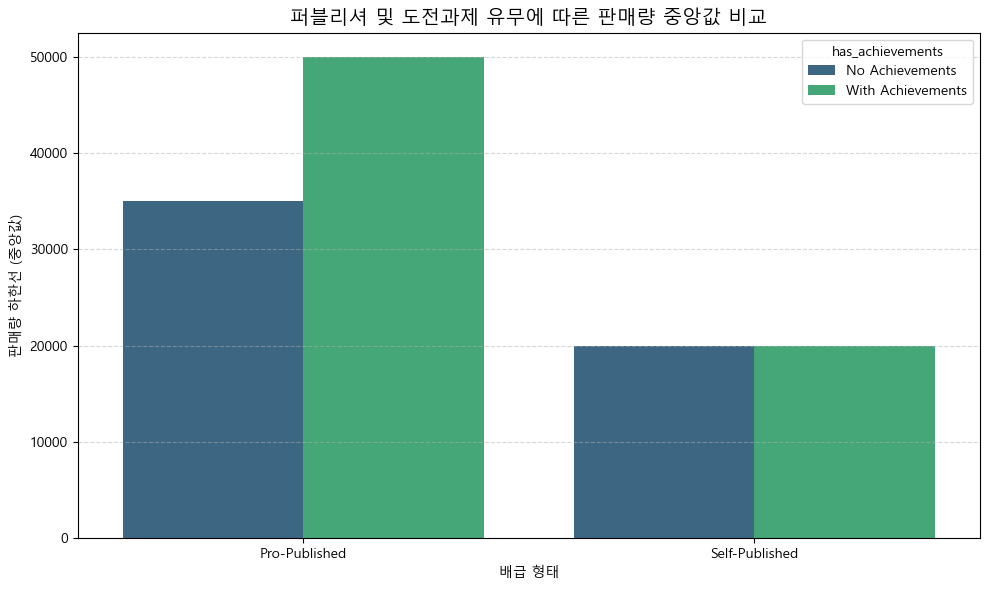

In [14]:
# 시각화 (상호작용 막대 그래프)
plt.figure(figsize=(10, 6))
sns.barplot(data=interaction_stats, x='pub_type', y='owners_lower', hue='has_achievements', palette='viridis')

plt.title('퍼블리셔 및 도전과제 유무에 따른 판매량 중앙값 비교', fontsize=14)
plt.ylabel('판매량 하한선 (중앙값)')
plt.xlabel('배급 형태')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [15]:
# 6. 결과 출력
print(f"독립성 검정 p-value: {p_val:.4f}") # 0.05보다 크면 두 변수는 서로 상관없이 독립적임
print("\n[상세 데이터]")
print(interaction_stats)

독립성 검정 p-value: 1.0000

[상세 데이터]
         pub_type   has_achievements  owners_lower
0   Pro-Published    No Achievements       35000.0
1   Pro-Published  With Achievements       50000.0
2  Self-Published    No Achievements       20000.0
3  Self-Published  With Achievements       20000.0
